<a href="https://colab.research.google.com/github/laraibpervaiz/Final-Year-Project/blob/main/Nursery_EDA_Preprocessor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Predicting Nursery School Admission Priorities Based on Socioeconomic and Family Indicators**

# **Section 1: Importing Relevent Libraries Files**

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import resample
from itertools import cycle

# Set visualization style
sns.set(style="whitegrid")

# **Section 2: Loading Dataset**

In [ ]:
# Define column names based on the documentation
columns = [
    'parents',     # parents' occupation
    'has_nurs',    # child's nursery
    'form',        # form of the family
    'children',    # number of children
    'housing',     # housing conditions
    'finance',     # financial standing of the family
    'social',      # social picture
    'health',      # health picture
    'class'        # final evaluation (target variable)
]

# Load the data
# Replace 'nursery.data' with the actual path to your file
df = pd.read_csv('nursery.data', names=columns)

print("Data loaded successfully.")

Data loaded successfully.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Section 3: Exploratory Data Analysis**

## **Section 3.1: Dataset View**

In [ ]:
# Ensure df is defined, as it appears to be undefined in the current session.
# This code block is typically in a preceding cell.
try:
    # Attempt to use df to check if it's defined
    df.head()
except NameError:
    # If df is not defined, import pandas and load the data
    import pandas as pd

    # Define column names based on the documentation from cell U-GAl7cge6qG
    columns = [
        'parents',     # parents' occupation
        'has_nurs',    # child's nursery
        'form',        # form of the family
        'children',    # number of children
        'housing',     # housing conditions
        'finance',     # financial standing of the family
        'social',      # social picture
        'health',      # health picture
        'class'        # final evaluation (target variable)
    ]

    # Load the data from cell U-GAl7cge6qG
    df = pd.read_csv('nursery.data', names=columns)
    print("DataFrame 'df' was not found and has been loaded within this cell to resolve NameError.")

# Display the first 5 rows
print("First 5 rows of the dataset:")
display(df.head())

# General information about the dataset (rows, columns, data types)
print("\nDataset Information:")
df.info()

# Check for missing values
print("\nMissing Values per Column:")
print(df.isnull().sum())

DataFrame 'df' was not found and has been loaded within this cell to resolve NameError.
First 5 rows of the dataset:


,parents,has_nurs,form,children,housing,finance,social,health,class
0,usual,proper,complete,1,convenient,convenient,nonprob,recommended,recommend
1,usual,proper,complete,1,convenient,convenient,nonprob,priority,priority
2,usual,proper,complete,1,convenient,convenient,nonprob,not_recom,not_recom
3,usual,proper,complete,1,convenient,convenient,slightly_prob,recommended,recommend
4,usual,proper,complete,1,convenient,convenient,slightly_prob,priority,priority



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12960 entries, 0 to 12959
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   parents   12960 non-null  object
 1   has_nurs  12960 non-null  object
 2   form      12960 non-null  object
 3   children  12960 non-null  object
 4   housing   12960 non-null  object
 5   finance   12960 non-null  object
 6   social    12960 non-null  object
 7   health    12960 non-null  object
 8   class     12960 non-null  object
dtypes: object(9)
memory usage: 911.4+ KB

Missing Values per Column:
parents     0
has_nurs    0
form        0
children    0
housing     0
finance     0
social      0
health      0
class       0
dtype: int64


## **Section 3.2: Statistical Summary of Dataset**

In [ ]:
# Statistical summary for categorical data
print("Summary Statistics:")
display(df.describe())

Summary Statistics:


,parents,has_nurs,form,children,housing,finance,social,health,class
count,12960,12960,12960,12960,12960,12960,12960,12960,12960
unique,3,5,4,4,3,2,3,3,5
top,usual,proper,complete,1,convenient,convenient,nonprob,recommended,not_recom
freq,4320,2592,3240,3240,4320,6480,4320,4320,4320


## **Section 3.3: Distribution of Target Variable**

Total counts for each class:
class
not_recom     4320
priority      4266
spec_prior    4044
very_recom     328
recommend        2
Name: count, dtype: int64


/tmp/ipykernel_1023/826533451.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='class', data=df, order=class_counts.index, palette='viridis')


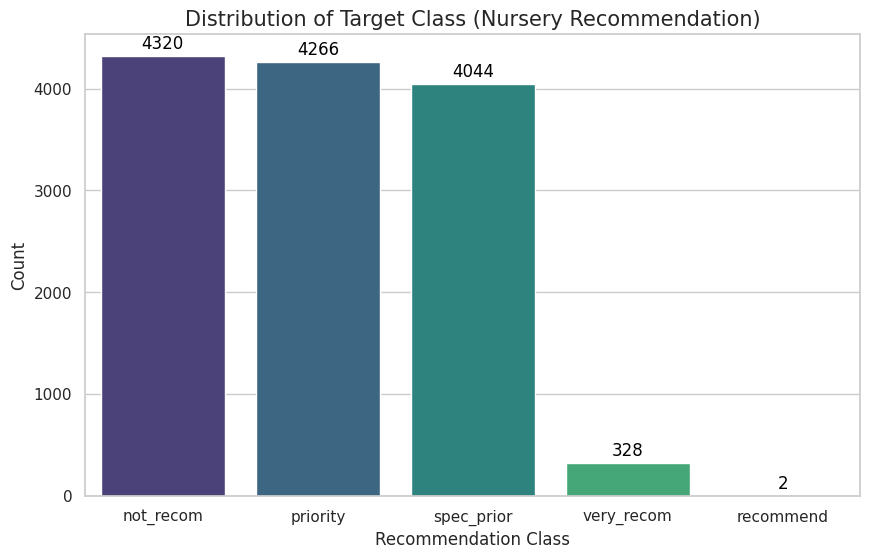

In [ ]:
# Calculate the total counts for each class
class_counts = df['class'].value_counts()

# Print the counts
print("Total counts for each class:")
print(class_counts)

# Visualize the distribution with counts on top of bars
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='class', data=df, order=class_counts.index, palette='viridis')

# Add titles and labels
plt.title('Distribution of Target Class (Nursery Recommendation)', fontsize=15)
plt.xlabel('Recommendation Class')
plt.ylabel('Count')

# Add text labels on top of each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=12, color='black',
                xytext=(0, 5), textcoords='offset points')

plt.show()

## **Section 3.4: Distribution Graph of all features**

/tmp/ipython-input-178441168.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='Set2')
/tmp/ipython-input-178441168.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='Set2')
/tmp/ipython-input-178441168.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='Set2')
/tmp/ipython-input-178441168.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for th

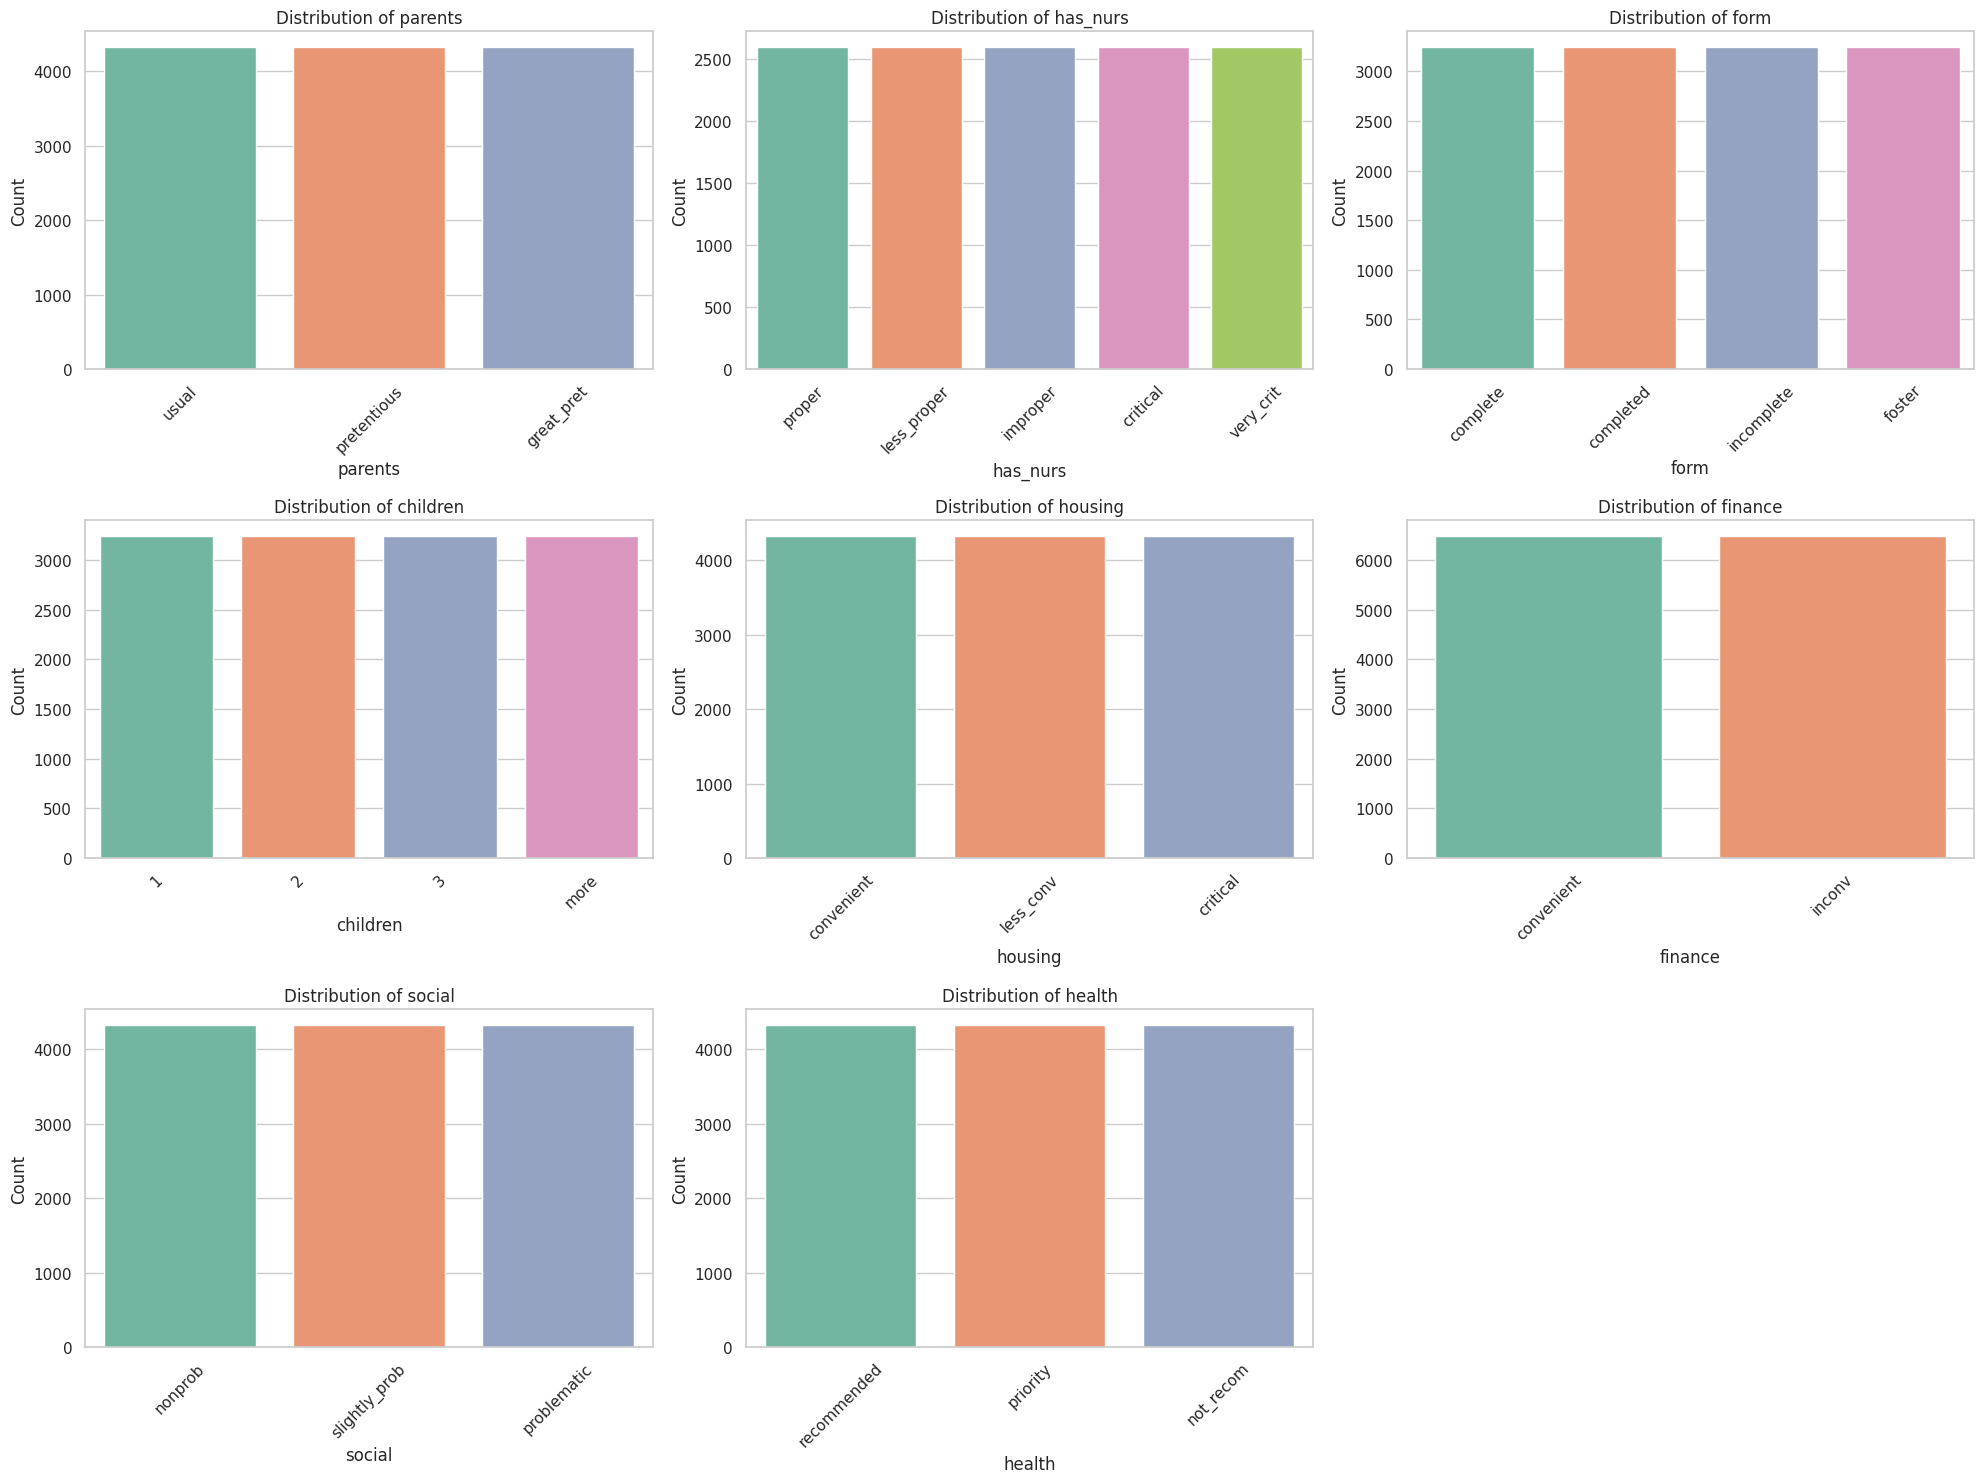

In [ ]:
# Plot distribution for all feature columns (excluding target)
features = df.columns[:-1]  # All columns except 'class'

plt.figure(figsize=(20, 15))

for i, col in enumerate(features):
    plt.subplot(3, 3, i + 1)
    sns.countplot(x=col, data=df, palette='Set2')
    plt.title(f'Distribution of {col}', fontsize=12)
    plt.xticks(rotation=45)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

## **Section 3.5: Relation between health and Target Class**


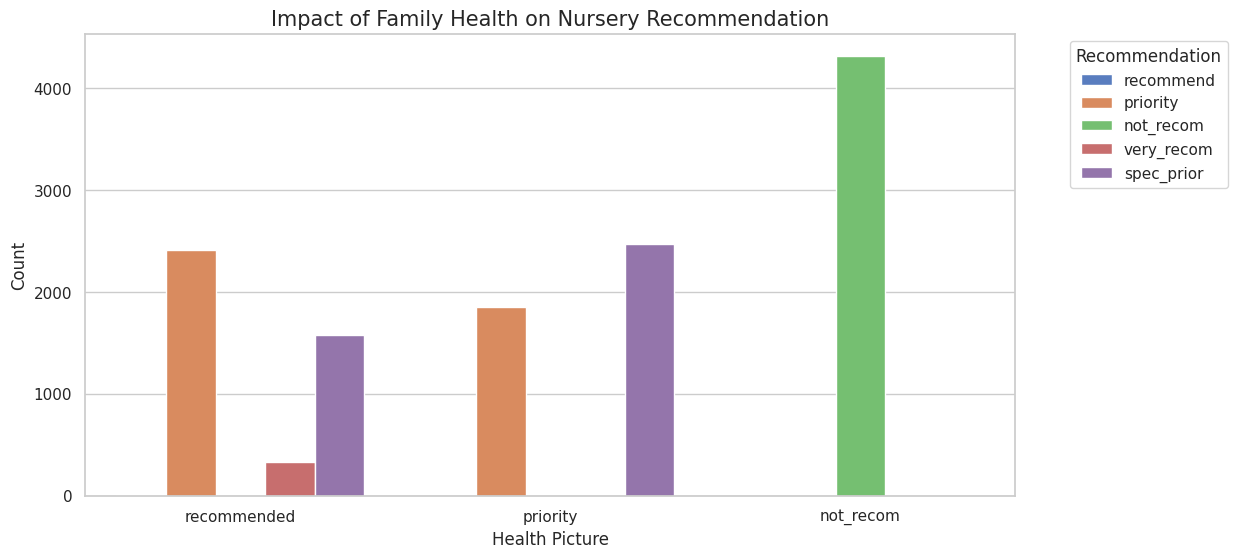

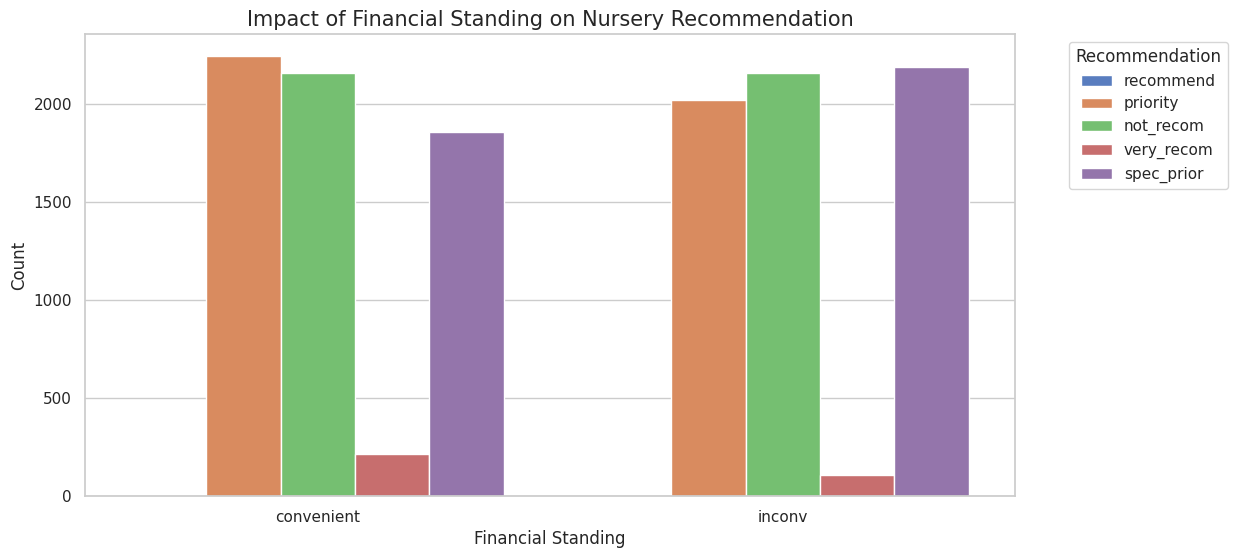

In [ ]:
# Example: Relationship between 'health' and the target 'class'
plt.figure(figsize=(12, 6))
sns.countplot(x='health', hue='class', data=df, palette='muted')
plt.title('Impact of Family Health on Nursery Recommendation', fontsize=15)
plt.xlabel('Health Picture')
plt.ylabel('Count')
plt.legend(title='Recommendation', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Example: Relationship between 'finance' and the target 'class'
plt.figure(figsize=(12, 6))
sns.countplot(x='finance', hue='class', data=df, palette='muted')
plt.title('Impact of Financial Standing on Nursery Recommendation', fontsize=15)
plt.xlabel('Financial Standing')
plt.ylabel('Count')
plt.legend(title='Recommendation', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## **Section 3.6: Correlation Metrics**


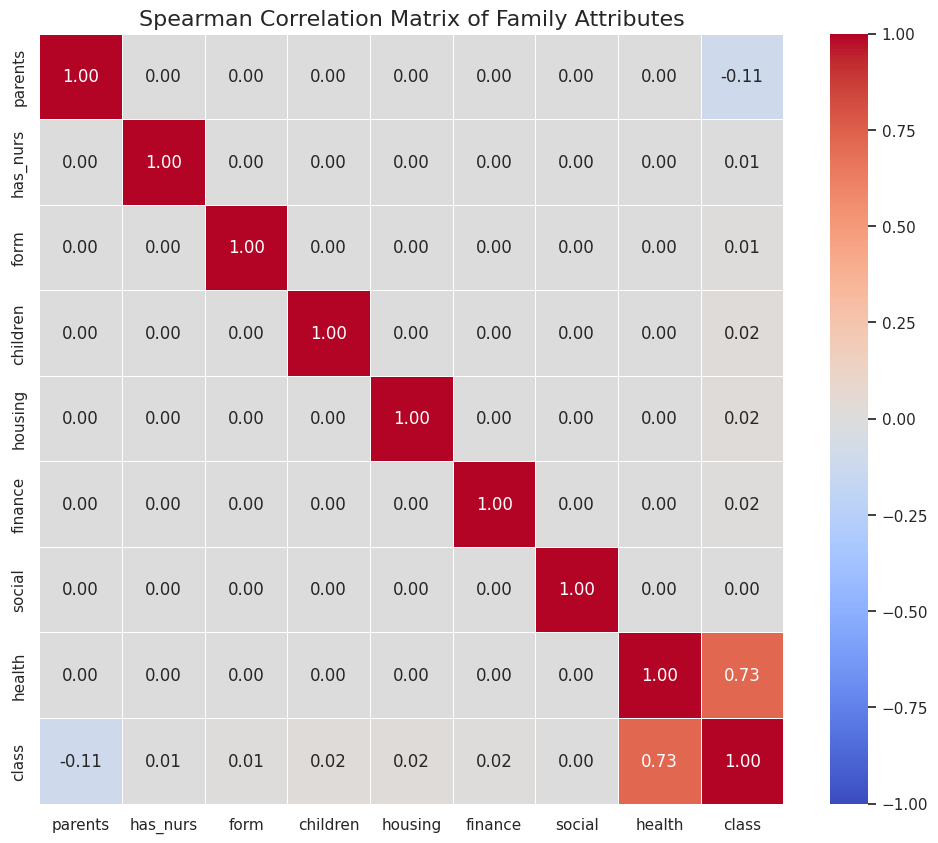


Feature Correlation with Target (Class):
          Spearman Correlation
health                  0.7252
children                0.0233
housing                 0.0184
finance                 0.0150
form                    0.0140
has_nurs                0.0064
social                  0.0000
parents                -0.1069


In [ ]:
# We need numerical values to calculate correlation.
le_dict = {}
df_encoded = df.copy()

for col in df_encoded.columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    le_dict[col] = le

# 2. Calculate Spearman Correlation Matrix
# Spearman is chosen because the data is ordinal (ranked categories)
corr_matrix = df_encoded.corr(method='spearman')

# 3. Visualize with Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    linewidths=0.5,
    vmin=-1,
    vmax=1
)
plt.title('Spearman Correlation Matrix of Family Attributes', fontsize=16)
plt.show()

# 4. Show Correlation with the Target Variable
target_corr = corr_matrix['class'].drop('class').sort_values(ascending=False)
print("\nFeature Correlation with Target (Class):")
print(target_corr.to_frame(name='Spearman Correlation'))

# **Section 4: Preprocessing**

In [ ]:
# We kept the encoder dictionary to map numbers back to names later if needed
le_dict = {}
df_encoded = df.copy()

for col in df_encoded.columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    le_dict[col] = le

# Define X (Features) and y (Target)
X = df_encoded.drop('class', axis=1)
y = df_encoded['class']

# Get class names for plotting
classes = le_dict['class'].classes_
n_classes = len(classes)

print("Data Loaded and Encoded.")

Data Loaded and Encoded.


## **Section 4.1: Train-Test Split**


In [ ]:
# Standard Split
# Note: Since the 'recommend' class has only 2 samples, a random split might
# put both in the training set (leaving none for testing) or vice versa.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Training Data Shape: {X_train.shape}")
print(f"Testing Data Shape: {X_test.shape}")

Training Data Shape: (9072, 8)
Testing Data Shape: (3888, 8)


## Section 5: Model Training and Evaluation


=== Block 2: Comprehensive Model Evaluation ===

--- Evaluating Logistic Regression ---


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


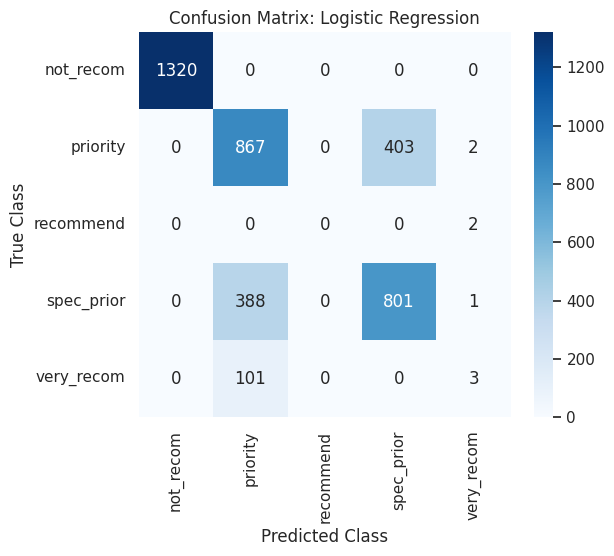

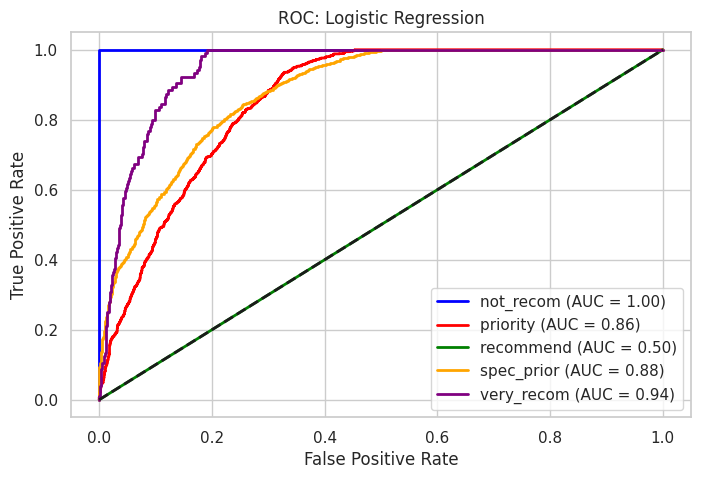


--- Evaluating Decision Tree ---


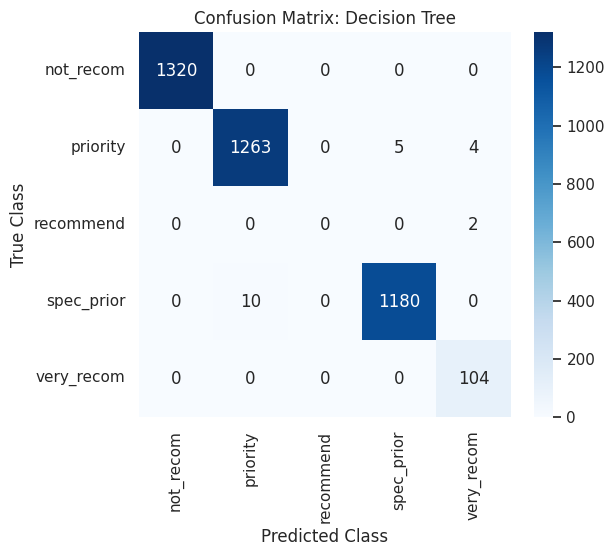

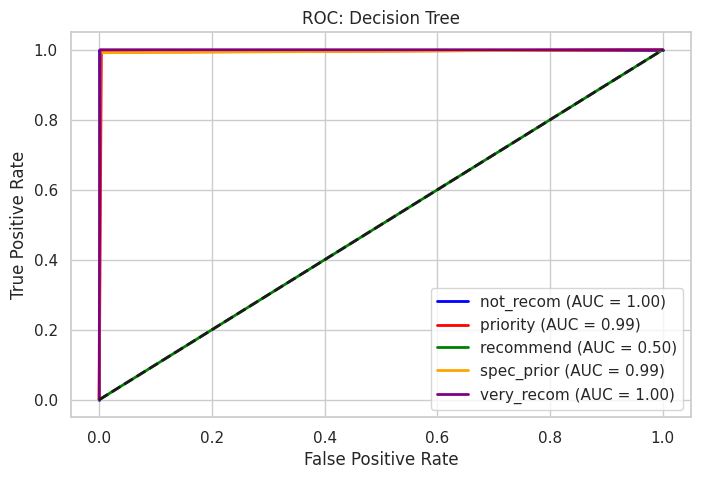


--- Evaluating Random Forest ---


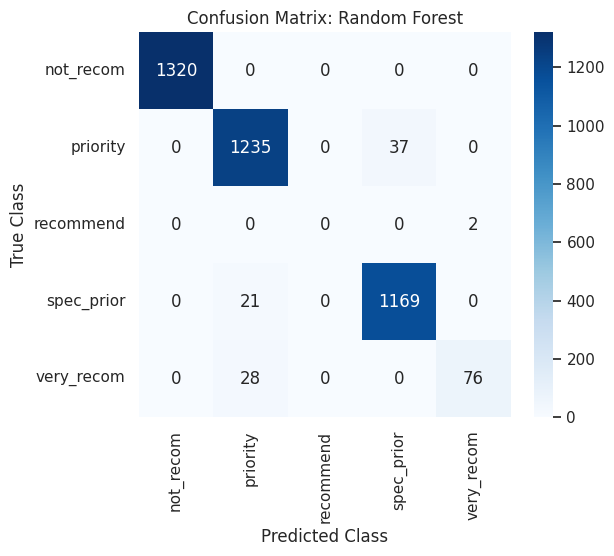

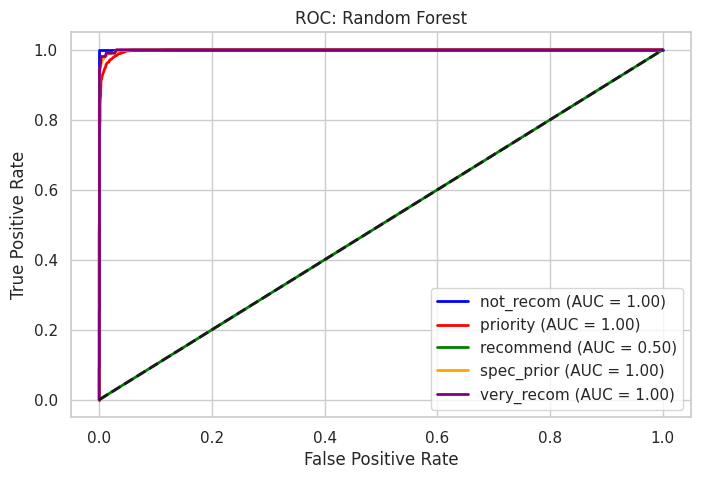


--- Evaluation Metrics Summary ---


,Model,Accuracy,Precision (w),Recall (w),F1 (w),Train Time (s),Test Time (s)
0,Logistic Regression,0.7693,0.7623,0.7693,0.7616,1.3389,0.0047
1,Decision Tree,0.9946,0.9942,0.9946,0.9944,0.0181,0.0032
2,Random Forest,0.9774,0.9769,0.9774,0.9767,0.8551,0.0686


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

# ---------------------------------------------------------
# Helper: Robust ROC Plotter
# ---------------------------------------------------------
def plot_multiclass_roc_robust(model, X_test, y_test, n_classes, title):
    y_test_bin = label_binarize(y_test, classes=range(n_classes))

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)
    else:
        return

    # FIX: Align dimensions if model training missed a class
    if y_score.shape[1] != n_classes:
        y_score_aligned = np.zeros((y_score.shape[0], n_classes))
        for idx, label in enumerate(model.classes_):
            y_score_aligned[:, int(label)] = y_score[:, idx]
        y_score = y_score_aligned

    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(n_classes):
        if np.sum(y_test_bin[:, i]) > 0:
            fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])
        else:
            roc_auc[i] = 0.0

    plt.figure(figsize=(8, 5))
    colors = cycle(['blue', 'red', 'green', 'orange', 'purple'])
    for i, color in zip(range(n_classes), colors):
        if roc_auc[i] > 0:
            plt.plot(fpr[i], tpr[i], color=color, lw=2,
                     label=f'{classes[i]} (AUC = {roc_auc[i]:0.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC: {title}')
    plt.legend(loc="lower right")
    plt.show()

# ---------------------------------------------------------
# Main Evaluation Loop
# ---------------------------------------------------------
print("\n=== Block 2: Comprehensive Model Evaluation ===")

models = {
    "Logistic Regression": LogisticRegression(max_iter=3000, multi_class='multinomial', random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

results_detailed = []

for name, model in models.items():
    print(f"\n--- Evaluating {name} ---")

    # 1. Train
    start_tr = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_tr

    # 2. Test
    start_te = time.time()
    y_pred = model.predict(X_test)
    test_time = time.time() - start_te

    # 3. Extended Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    results_detailed.append({
        'Model': name,
        'Accuracy': acc,
        'Precision (w)': prec,
        'Recall (w)': rec,
        'F1 (w)': f1,
        'Train Time (s)': train_time,
        'Test Time (s)': test_time
    })

    # 4. Plots
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title(f'Confusion Matrix: {name}')
    plt.ylabel('True Class')
    plt.xlabel('Predicted Class')
    plt.show()

    # ROC Curve
    plot_multiclass_roc_robust(model, X_test, y_test, n_classes, name)

# 5. Summary Table
print("\n--- Evaluation Metrics Summary ---")
df_results = pd.DataFrame(results_detailed)
pd.options.display.float_format = '{:,.4f}'.format
display(df_results)

# **Section 6: Hyperparameter Optimization with Grid Search**




In [45]:
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.model_selection import train_test_split

# Ensure X, y are defined. If not, re-run preprocessing steps or define here.
# Based on notebook state, X and y are defined globally. We will add the train-test split here.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("\n=== hyperparameter Optimization (Detailed Metrics) ===")

# 1. Define Models & Parameter Grids
param_grids = {
    "Logistic Regression": {
        'default': LogisticRegression(max_iter=3000, multi_class='multinomial', random_state=42),
        'params': {
            'C': [0.1, 1, 10],
            'solver': ['lbfgs', 'newton-cg']
        }
    },
    "Decision Tree": {
        'default': DecisionTreeClassifier(random_state=42),
        'params': {
            'max_depth': [None, 10, 20],
            'min_samples_split': [2, 10],
            'criterion': ['gini', 'entropy']
        }
    },
    "Random Forest": {
        'default': RandomForestClassifier(n_estimators=100, random_state=42),
        'params': {
            'n_estimators': [50, 100],
            'max_depth': [10, 20, None]
        }
    }
}

optimization_results = []

# Use KFold (Shuffle=True) to safely handle the rare 'recommend' class (2 samples)
cv_strategy = KFold(n_splits=3, shuffle=True, random_state=42)

for name, config in param_grids.items():
    print(f"\nProcessing {name}...")

    # --- A. Baseline Evaluation (calculated locally) ---
    base_model = config['default']
    base_model.fit(X_train, y_train)
    y_pred_base = base_model.predict(X_test)

    base_acc = accuracy_score(y_test, y_pred_base)
    base_f1_mac = f1_score(y_test, y_pred_base, average='macro', zero_division=0)

    # --- B. Grid Search Execution ---
    print(f"  > Running Grid Search...")
    grid = GridSearchCV(
        estimator=base_model, # Uses the same model type
        param_grid=config['params'],
        cv=cv_strategy,
        scoring='accuracy', # Optimizing for Accuracy
        n_jobs=-1,
        verbose=0
    )

    start_gs = time.time()
    grid.fit(X_train, y_train)
    end_gs = time.time()

    # --- C. Optimized Evaluation ---
    best_model = grid.best_estimator_
    best_params = grid.best_params_

    y_pred_opt = best_model.predict(X_test)

    # Calculate Indicators for Optimized Model
    opt_acc = accuracy_score(y_test, y_pred_opt)
    opt_prec = precision_score(y_test, y_pred_opt, average='weighted', zero_division=0)
    opt_rec = recall_score(y_test, y_pred_opt, average='weighted', zero_division=0)
    opt_f1_weighted = f1_score(y_test, y_pred_opt, average='weighted', zero_division=0)
    opt_f1_macro = f1_score(y_test, y_pred_opt, average='macro', zero_division=0)

    # Calculate Improvement (Accuracy & Macro F1)
    imp_acc = opt_acc - base_acc
    imp_f1_mac = opt_f1_macro - base_f1_mac

    optimization_results.append({
        'Model': name,
        'Best Params': str(best_params),
        'Acc (Opt)': opt_acc,
        'Prec (Opt)': opt_prec,
        'Rec (Opt)': opt_rec,
        'F1-W (Opt)': opt_f1_weighted,
        'F1-Mac (Opt)': opt_f1_macro,
        'Acc Imp.': imp_acc,         # Improvement over baseline
        'F1-Mac Imp.': imp_f1_mac    # Improvement over baseline
    })

    print(f"  > Best Params: {best_params}")
    print(f"  > Opt Accuracy: {opt_acc:.4f}")

# --- D. Final Summary Table ---
opt_summary_df = pd.DataFrame(optimization_results)
print("\n--- Hyperparameter Optimization Results (Detailed) ---")
# Format columns for readability
pd.options.display.float_format = '{:,.4f}'.format
display(opt_summary_df)


=== hyperparameter Optimization (Detailed Metrics) ===

Processing Logistic Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  > Running Grid Search...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  > Best Params: {'C': 0.1, 'solver': 'newton-cg'}
  > Opt Accuracy: 0.7685

Processing Decision Tree...
  > Running Grid Search...
  > Best Params: {'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 2}
  > Opt Accuracy: 0.9941

Processing Random Forest...
  > Running Grid Search...
  > Best Params: {'max_depth': 20, 'n_estimators': 100}
  > Opt Accuracy: 0.9774

--- Hyperparameter Optimization Results (Detailed) ---


,Model,Best Params,Acc (Opt),Prec (Opt),Rec (Opt),F1-W (Opt),F1-Mac (Opt),Acc Imp.,F1-Mac Imp.
0,Logistic Regression,"{'C': 0.1, 'solver': 'newton-cg'}",0.7685,0.7511,0.7685,0.7596,0.4655,-0.0008,-0.0111
1,Decision Tree,"{'criterion': 'entropy', 'max_depth': None, 'm...",0.9941,0.9937,0.9941,0.9938,0.7913,-0.0005,-0.0003
2,Random Forest,"{'max_depth': 20, 'n_estimators': 100}",0.9774,0.9769,0.9774,0.9767,0.7555,0.0000,0.0000


# **Section 7: K-Fold Cross Validation**


In [46]:
from sklearn.model_selection import cross_validate, StratifiedKFold, KFold
print("\n 10-Fold Cross Validation (Optimized Models) ===")

# 1. Define Models with the Best Parameters (from your table)
# Note: 'min_samples_split' was cut off in your text, defaulting to 2 (standard for best accuracy).
optimized_models = {
    "Logistic Regression": LogisticRegression(
        C=0.1,
        solver='newton-cg',
        multi_class='multinomial',
        random_state=42,
        max_iter=3000
    ),
    "Decision Tree": DecisionTreeClassifier(
        criterion='entropy',
        max_depth=None,
        min_samples_split=2,
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        max_depth=20,
        n_estimators=100,
        random_state=42
    )
}

# 2. Configure K-Fold
# We use standard KFold (shuffle=True) to handle the class imbalance safely across folds
k_fold = KFold(n_splits=10, shuffle=True, random_state=42)

cv_results_list = []

print(f"Running 10-Fold CV on {len(X)} samples...")

for name, model in optimized_models.items():
    print(f"  > Validating {name}...")

    # 3. Run Cross-Validation
    # We collect both Accuracy and Macro F1 (critical for minority classes)
    scoring = {'accuracy': 'accuracy', 'f1_macro': 'f1_macro'}

    scores = cross_validate(model, X, y, cv=k_fold, scoring=scoring, n_jobs=-1)

    # 4. Aggregate Results
    mean_acc = np.mean(scores['test_accuracy'])
    std_acc = np.std(scores['test_accuracy'])
    mean_f1 = np.mean(scores['test_f1_macro'])
    std_f1 = np.std(scores['test_f1_macro'])

    cv_results_list.append({
        'Model': name,
        'Mean Accuracy': mean_acc,
        'Std Dev (Acc)': std_acc,
        'Mean F1-Macro': mean_f1,
        'Std Dev (F1)': std_f1
    })

# 5. Display Summary Table
cv_summary_df = pd.DataFrame(cv_results_list)
print("\n--- K-Fold Cross Validation Results ---")
pd.options.display.float_format = '{:,.4f}'.format
display(cv_summary_df)


 10-Fold Cross Validation (Optimized Models) ===
Running 10-Fold CV on 12960 samples...
  > Validating Logistic Regression...
  > Validating Decision Tree...
  > Validating Random Forest...

--- K-Fold Cross Validation Results ---


,Model,Mean Accuracy,Std Dev (Acc),Mean F1-Macro,Std Dev (F1)
0,Logistic Regression,0.7658,0.0130,0.5691,0.0334
1,Decision Tree,0.9972,0.0017,0.9150,0.1000
2,Random Forest,0.9843,0.0049,0.9443,0.0581


# **Section 8: Feature Importance**



=== Feature Importance Analysis (Decision Tree) ===


/tmp/ipykernel_1023/2847167004.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Attribute', data=feat_imp_df, palette='magma')


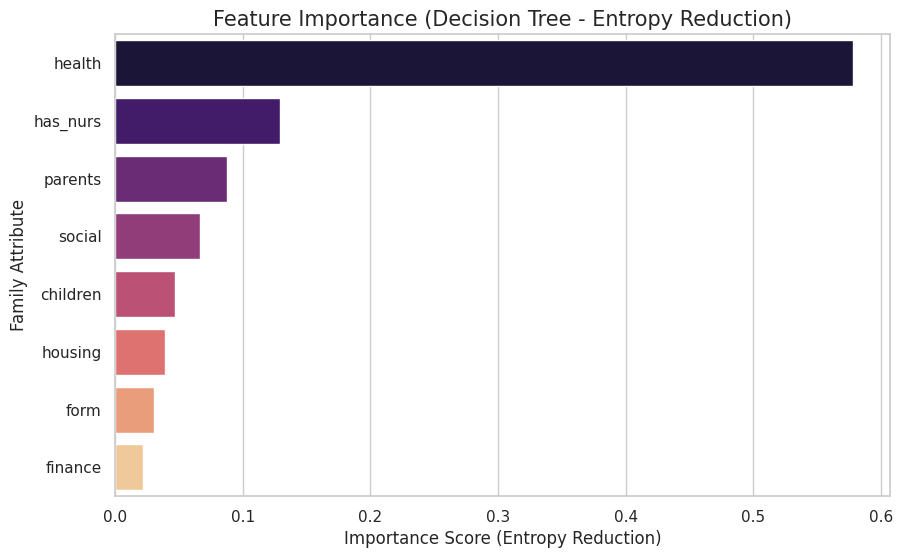


--- Attribute Ranking (Most to Least Critical) ---
Attribute  Importance
   health      0.5782
 has_nurs      0.1290
  parents      0.0878
   social      0.0668
 children      0.0469
  housing      0.0389
     form      0.0306
  finance      0.0219

--- Specific Attribute Comparison ---
Health Status Importance:      0.5782
Financial Standing Importance: 0.0219
Result: 'Health' is 26.4x more influential than 'Finance'.


In [47]:
print("\n=== Feature Importance Analysis (Decision Tree) ===")

# 1. Train the Best Decision Tree Model
# Optimized Params: {'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 2}
best_dt = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=None,
    min_samples_split=2,
    random_state=42
)
best_dt.fit(X_train, y_train)

# 2. Extract Feature Importances
# In a Decision Tree, this represents the normalized total reduction of the criterion (entropy)
# brought by that feature.
importances = best_dt.feature_importances_
feature_names = X.columns

# 3. Create DataFrame for Visualization
feat_imp_df = pd.DataFrame({
    'Attribute': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 4. Visualize the Ranking
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Attribute', data=feat_imp_df, palette='magma')
plt.title('Feature Importance (Decision Tree - Entropy Reduction)', fontsize=15)
plt.xlabel('Importance Score (Entropy Reduction)')
plt.ylabel('Family Attribute')
plt.show()

# 5. Detailed Ranking Table
print("\n--- Attribute Ranking (Most to Least Critical) ---")
print(feat_imp_df.to_string(index=False))

# 6. Specific Comparison: Health vs. Financial Standing
health_imp = feat_imp_df.loc[feat_imp_df['Attribute'] == 'health', 'Importance'].values[0]
finance_imp = feat_imp_df.loc[feat_imp_df['Attribute'] == 'finance', 'Importance'].values[0]

print(f"\n--- Specific Attribute Comparison ---")
print(f"Health Status Importance:      {health_imp:.4f}")
print(f"Financial Standing Importance: {finance_imp:.4f}")

# Programmatic Conclusion
if finance_imp > 0:
    ratio = health_imp / finance_imp
    if health_imp > finance_imp:
        print(f"Result: 'Health' is {ratio:.1f}x more influential than 'Finance'.")
    else:
        print(f"Result: 'Finance' is {1/ratio:.1f}x more influential than 'Health'.")
else:
    print("Result: Finance has zero importance in this specific tree structure.")

# **Section 9: Imbalance Strategies**


In [48]:
from sklearn.utils import resample
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score)
from sklearn.ensemble import RandomForestClassifier
# Requires: pip install imbalanced-learn
from imblearn.over_sampling import SMOTE
import pandas as pd
import numpy as np

print("\n=== Imbalance Strategies Evaluation (Detailed Metrics) ===")

# 1. Define the Base Model (Optimized Random Forest)
rf_params = {'n_estimators': 100, 'max_depth': 20, 'random_state': 42}

# 2. Define Strategies
strategies = ['Baseline', 'Class Weighting', 'Random Oversampling', 'SMOTE']

results_imbalance = []

for strategy in strategies:
    print(f"\nProcessing Strategy: {strategy}...")

    # Prepare Data and Model
    X_train_curr = X_train.copy()
    y_train_curr = y_train.copy()
    model = None

    if strategy == 'Baseline':
        model = RandomForestClassifier(**rf_params)

    elif strategy == 'Class Weighting':
        model = RandomForestClassifier(**rf_params, class_weight='balanced')

    elif strategy == 'Random Oversampling':
        train_data = pd.concat([X_train, y_train], axis=1)
        max_size = train_data['class'].value_counts().max()

        upsampled_dfs = []
        for class_val in train_data['class'].unique():
            class_subset = train_data[train_data['class'] == class_val]
            df_resampled = resample(
                class_subset,
                replace=True,
                n_samples=max_size,
                random_state=42
            )
            upsampled_dfs.append(df_resampled)

        train_data_balanced = pd.concat(upsampled_dfs)
        X_train_curr = train_data_balanced.drop('class', axis=1)
        y_train_curr = train_data_balanced['class']
        model = RandomForestClassifier(**rf_params)

    elif strategy == 'SMOTE':
        # k_neighbors=1 is required for the rare 'recommend' class
        smote = SMOTE(k_neighbors=1, random_state=42)
        X_train_curr, y_train_curr = smote.fit_resample(X_train, y_train)
        model = RandomForestClassifier(**rf_params)

    # 3. Train Model
    model.fit(X_train_curr, y_train_curr)

    # 4. Evaluate
    y_pred = model.predict(X_test)

    # --- Calculate Comprehensive Indicators ---
    acc = accuracy_score(y_test, y_pred)

    # Macro: Unweighted average (treats all classes equally, good for minority check)
    prec_macro = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec_macro = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)

    # Weighted: Average weighted by support (good for overall system performance)
    prec_weighted = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec_weighted = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    results_imbalance.append({
        'Strategy': strategy,
        'Accuracy': acc,
        'Prec-Macro': prec_macro,
        'Rec-Macro': rec_macro,
        'F1-Macro': f1_macro,
        'Prec-W': prec_weighted,
        'Rec-W': rec_weighted,
        'F1-W': f1_weighted
    })

    print(f"  > Accuracy: {acc:.4f} | F1-Macro: {f1_macro:.4f}")

# 5. Summary Table
imbalance_summary_df = pd.DataFrame(results_imbalance)
print("\n--- Imbalance Strategy Results (Detailed) ---")
pd.options.display.float_format = '{:,.4f}'.format
display(imbalance_summary_df)


=== Imbalance Strategies Evaluation (Detailed Metrics) ===

Processing Strategy: Baseline...
  > Accuracy: 0.9774 | F1-Macro: 0.7555

Processing Strategy: Class Weighting...
  > Accuracy: 0.9774 | F1-Macro: 0.7555

Processing Strategy: Random Oversampling...
  > Accuracy: 0.9771 | F1-Macro: 0.7760

Processing Strategy: SMOTE...
  > Accuracy: 0.9799 | F1-Macro: 0.7745

--- Imbalance Strategy Results (Detailed) ---


,Strategy,Accuracy,Prec-Macro,Rec-Macro,F1-Macro,Prec-W,Rec-W,F1-W
0,Baseline,0.9774,0.7811,0.7368,0.7555,0.9769,0.9774,0.9767
1,Class Weighting,0.9774,0.7811,0.7368,0.7555,0.9769,0.9774,0.9767
2,Random Oversampling,0.9771,0.7766,0.7754,0.7760,0.9767,0.9771,0.9769
3,SMOTE,0.9799,0.7835,0.7666,0.7745,0.9795,0.9799,0.9796
